In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

# Predicción de ESCNNA (Clasificación)

1. Preparación de Datos
2. División de los datos 70-30
3. Aprendizaje del Modelo
4. Evaluación del Modelo: matriz de confusion, P,R, ROC
5. Guardar el modelo

* El despliegue se realiza en otro jupyter_notebook

In [ ]:
#Importamos librerías básicas
import pandas as pd # manipulacion dataframes
import numpy as np  # matrices y vectores
import matplotlib.pyplot as plt #gráfica

# 1. Preparación de Datos


In [ ]:
#Cargamos los datos
data = pd.read_excel("dataset_final.xlsx", sheet_name="Data")
data.head()

,DEPARTAMENTO,ARTICULO,CIRCUNSTACIA_DE_LA_CAPTURA,GENERO,Riesgo_Departamento,Momento_Delito,Tipo_Victima,Tipo_Delito,Entorno,Reincidencia
0,SANTANDER,ARTÍCULO 209,FLAGRANCIA LEY 906,MASCULINO,Bajo,Noche,Adolescente,Explotacion,Rural_Disperso,No
1,VALLE DEL CAUCA,ARTÍCULO 208,ORDEN JUDICIAL LEY 906,MASCULINO,Medio,Madrugada,Adolescente,Pornografia,Rural_Concentrado,No
2,VALLE DEL CAUCA,ARTÍCULO 209,ORDEN JUDICIAL LEY 906,MASCULINO,Medio,Noche,Niña,Acceso_Carnal,Urbano_Central,No
3,ATLÁNTICO,ARTÍCULO 209,ORDEN JUDICIAL LEY 906,MASCULINO,Bajo,Noche,Adolescente,Explotacion,Rural_Disperso,No
4,CUNDINAMARCA,ARTÍCULO 211,ORDEN JUDICIAL LEY 906,MASCULINO,Alto,Dia,Adolescente,Explotacion,Rural_Disperso,No


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   DEPARTAMENTO                631 non-null    object
 1   ARTICULO                    631 non-null    object
 2   CIRCUNSTACIA_DE_LA_CAPTURA  631 non-null    object
 3   GENERO                      631 non-null    object
 4   Riesgo_Departamento         631 non-null    object
 5   Momento_Delito              631 non-null    object
 6   Tipo_Victima                631 non-null    object
 7   Tipo_Delito                 631 non-null    object
 8   Entorno                     631 non-null    object
 9   Reincidencia                631 non-null    object
dtypes: object(10)
memory usage: 49.4+ KB


In [ ]:
#Corrección tipos de datos
data['DEPARTAMENTO']=data['DEPARTAMENTO'].astype('category')
data['ARTICULO']=data['ARTICULO'].astype('category')
data['CIRCUNSTACIA_DE_LA_CAPTURA']=data['CIRCUNSTACIA_DE_LA_CAPTURA'].astype('category')
data['GENERO']=data['GENERO'].astype('category')
data['Riesgo_Departamento']=data['Riesgo_Departamento'].astype('category')
data['Momento_Delito']=data['Momento_Delito'].astype('category')
data['Tipo_Victima']=data['Tipo_Victima'].astype('category')
data['Tipo_Delito']=data['Tipo_Delito'].astype('category')
data['Entorno']=data['Entorno'].astype('category')
data['Reincidencia']=data['Reincidencia'].astype('category')


data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 631 entries, 0 to 630
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   DEPARTAMENTO                631 non-null    category
 1   ARTICULO                    631 non-null    category
 2   CIRCUNSTACIA_DE_LA_CAPTURA  631 non-null    category
 3   GENERO                      631 non-null    category
 4   Riesgo_Departamento         631 non-null    category
 5   Momento_Delito              631 non-null    category
 6   Tipo_Victima                631 non-null    category
 7   Tipo_Delito                 631 non-null    category
 8   Entorno                     631 non-null    category
 9   Reincidencia                631 non-null    category
dtypes: category(10)
memory usage: 8.2 KB


In [ ]:
# Instalar pandas profiling

!pip install ydata-profiling

In [ ]:
# Cargar librería para Profiling
from pandas_profiling import ProfileReport

profile_data=ProfileReport(data, minimal=False) # minimal=True
profile_data

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 41.93it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
#Guardamos en html el perfilado de datos
profile_data.to_file(output_file="output.html")

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

<Axes: xlabel='Reincidencia'>

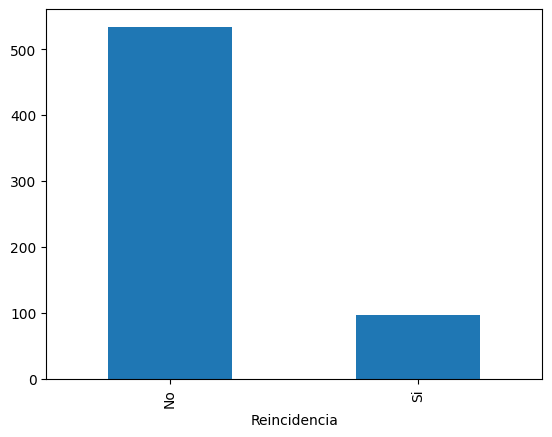

In [ ]:
data['Reincidencia'].value_counts().plot(kind='bar')

##BALANCEO DE LA VARIABLE OBJETIVO

Distribución original:
 Reincidencia
No    534
Si     97
Name: count, dtype: int64

Nueva distribución:
 Reincidencia
No    534
Si    267
Name: count, dtype: int64


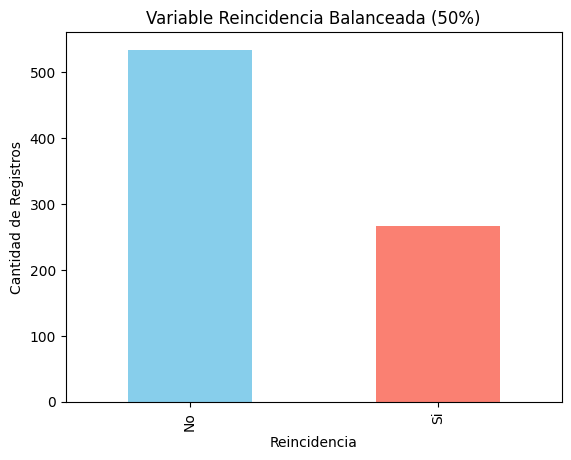

In [ ]:
#La clase minoritaria tendrá el 50% del tamaño de la clase mayoritaria, adicionando datos sintéticos

from imblearn.over_sampling import SMOTEN, SMOTENC


# 1. SEPARAR VARIABLES
X = data.drop("Reincidencia", axis=1)
Y = data['Reincidencia']

# 2. ELECCIÓN DEL MÉTODO
# Si TODAS son categóricas, usamos SMOTEN:
sampler = SMOTEN(
    sampling_strategy=0.5, # La clase "Si" será el 50% de la "No"
    k_neighbors=2,         # Útil para grupos pequeños
    random_state=42
)


# 3. APLICAR EL BALANCEO
X_res, y_res = sampler.fit_resample(X, Y)

# 4. RECONSTRUIR EL DATAFRAME BALANCEADO
data_bal = pd.DataFrame(X_res, columns=X.columns)
data_bal['Reincidencia'] = y_res

# 5. VISUALIZACIÓN DE RESULTADOS
print("Distribución original:\n", Y.value_counts())
print("\nNueva distribución:\n", data_bal['Reincidencia'].value_counts())

data_bal['Reincidencia'].value_counts().plot(
    kind='bar',
    color=['skyblue', 'salmon'],
    title='Variable Reincidencia Balanceada (50%)'
)
plt.ylabel('Cantidad de Registros')
plt.show()

In [ ]:
data_bal.head()

,DEPARTAMENTO,ARTICULO,CIRCUNSTACIA_DE_LA_CAPTURA,GENERO,Riesgo_Departamento,Momento_Delito,Tipo_Victima,Tipo_Delito,Entorno,Reincidencia
0,SANTANDER,ARTÍCULO 209,FLAGRANCIA LEY 906,MASCULINO,Bajo,Noche,Adolescente,Explotacion,Rural_Disperso,No
1,VALLE DEL CAUCA,ARTÍCULO 208,ORDEN JUDICIAL LEY 906,MASCULINO,Medio,Madrugada,Adolescente,Pornografia,Rural_Concentrado,No
2,VALLE DEL CAUCA,ARTÍCULO 209,ORDEN JUDICIAL LEY 906,MASCULINO,Medio,Noche,Niña,Acceso_Carnal,Urbano_Central,No
3,ATLÁNTICO,ARTÍCULO 209,ORDEN JUDICIAL LEY 906,MASCULINO,Bajo,Noche,Adolescente,Explotacion,Rural_Disperso,No
4,CUNDINAMARCA,ARTÍCULO 211,ORDEN JUDICIAL LEY 906,MASCULINO,Alto,Dia,Adolescente,Explotacion,Rural_Disperso,No


### Codificamos la variable objetivo (No=0, Si=1)

In [ ]:
# Codificamos la variable objetivo (No=0, Si=1)
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
data_bal["Reincidencia"] = labelencoder.fit_transform(data_bal["Reincidencia"])
data_bal.head()

,DEPARTAMENTO,ARTICULO,CIRCUNSTACIA_DE_LA_CAPTURA,GENERO,Riesgo_Departamento,Momento_Delito,Tipo_Victima,Tipo_Delito,Entorno,Reincidencia
0,SANTANDER,ARTÍCULO 209,FLAGRANCIA LEY 906,MASCULINO,Bajo,Noche,Adolescente,Explotacion,Rural_Disperso,0
1,VALLE DEL CAUCA,ARTÍCULO 208,ORDEN JUDICIAL LEY 906,MASCULINO,Medio,Madrugada,Adolescente,Pornografia,Rural_Concentrado,0
2,VALLE DEL CAUCA,ARTÍCULO 209,ORDEN JUDICIAL LEY 906,MASCULINO,Medio,Noche,Niña,Acceso_Carnal,Urbano_Central,0
3,ATLÁNTICO,ARTÍCULO 209,ORDEN JUDICIAL LEY 906,MASCULINO,Bajo,Noche,Adolescente,Explotacion,Rural_Disperso,0
4,CUNDINAMARCA,ARTÍCULO 211,ORDEN JUDICIAL LEY 906,MASCULINO,Alto,Dia,Adolescente,Explotacion,Rural_Disperso,0


In [ ]:
data_bal.columns

Index(['DEPARTAMENTO', 'ARTICULO', 'CIRCUNSTACIA_DE_LA_CAPTURA', 'GENERO',
       'Riesgo_Departamento', 'Momento_Delito', 'Tipo_Victima', 'Tipo_Delito',
       'Entorno', 'Reincidencia'],
      dtype='object')

###Dummies para las variables predictoras

In [ ]:
#Dummies para las variables predictoras
data_bal = pd.get_dummies(data_bal, columns=['DEPARTAMENTO', 'ARTICULO', 'CIRCUNSTACIA_DE_LA_CAPTURA', 'Riesgo_Departamento', 'Momento_Delito', 'Tipo_Victima', 'Tipo_Delito',
       'Entorno'], drop_first=False, dtype=int)
data_bal = pd.get_dummies(data_bal, columns=['GENERO'], drop_first=True, dtype=int)

data_bal.head()


,Reincidencia,DEPARTAMENTO_ANTIOQUIA,DEPARTAMENTO_ATLÁNTICO,DEPARTAMENTO_CUNDINAMARCA,DEPARTAMENTO_HUILA,DEPARTAMENTO_MAGDALENA,DEPARTAMENTO_META,DEPARTAMENTO_SANTANDER,DEPARTAMENTO_TOLIMA,DEPARTAMENTO_VALLE DEL CAUCA,...,Tipo_Victima_Niño,Tipo_Delito_Abuso,Tipo_Delito_Acceso_Carnal,Tipo_Delito_Explotacion,Tipo_Delito_Pornografia,Entorno_Rural_Concentrado,Entorno_Rural_Disperso,Entorno_Urbano_Central,Entorno_Urbano_Periferico,GENERO_MASCULINO
0,0,0,0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,1,0,0,1
1,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,1,1,0,0,0,1
2,0,0,0,0,0,0,0,0,0,1,...,0,0,1,0,0,0,0,1,0,1
3,0,0,1,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,1
4,0,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,1


#2. División 70-30

<Axes: xlabel='Reincidencia'>

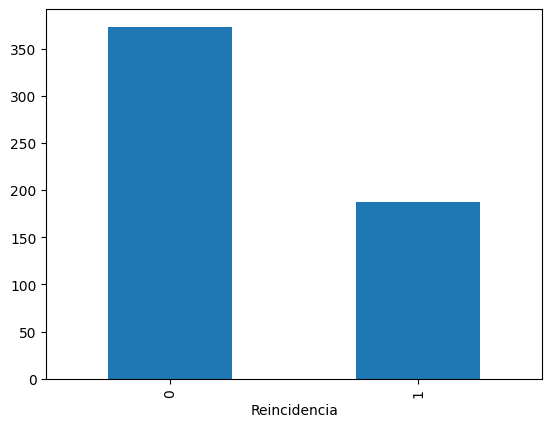

In [ ]:
#División 70-30
from sklearn.model_selection import train_test_split
X = data_bal.drop("Reincidencia", axis = 1) # Variables predictoras
Y = data_bal['Reincidencia'] #Variable objetivo
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, stratify=Y) #Muestreo estratificado
Y_train.value_counts().plot(kind='bar')

#3. Aprendizaje con el 70% y Evaluación con el 30%

In [ ]:
#Creación del modelo con el conjunto de entrenamiento
from sklearn.tree import DecisionTreeClassifier #DecisionTreeRegressor

modelTree = DecisionTreeClassifier(criterion='gini',min_samples_leaf=10, max_depth=9, class_weight='balanced', random_state=42) #gini, entropy
modelTree.fit(X_train, Y_train) #70% train


DecisionTreeClassifier(class_weight='balanced', max_depth=9,
                       min_samples_leaf=10, random_state=42)

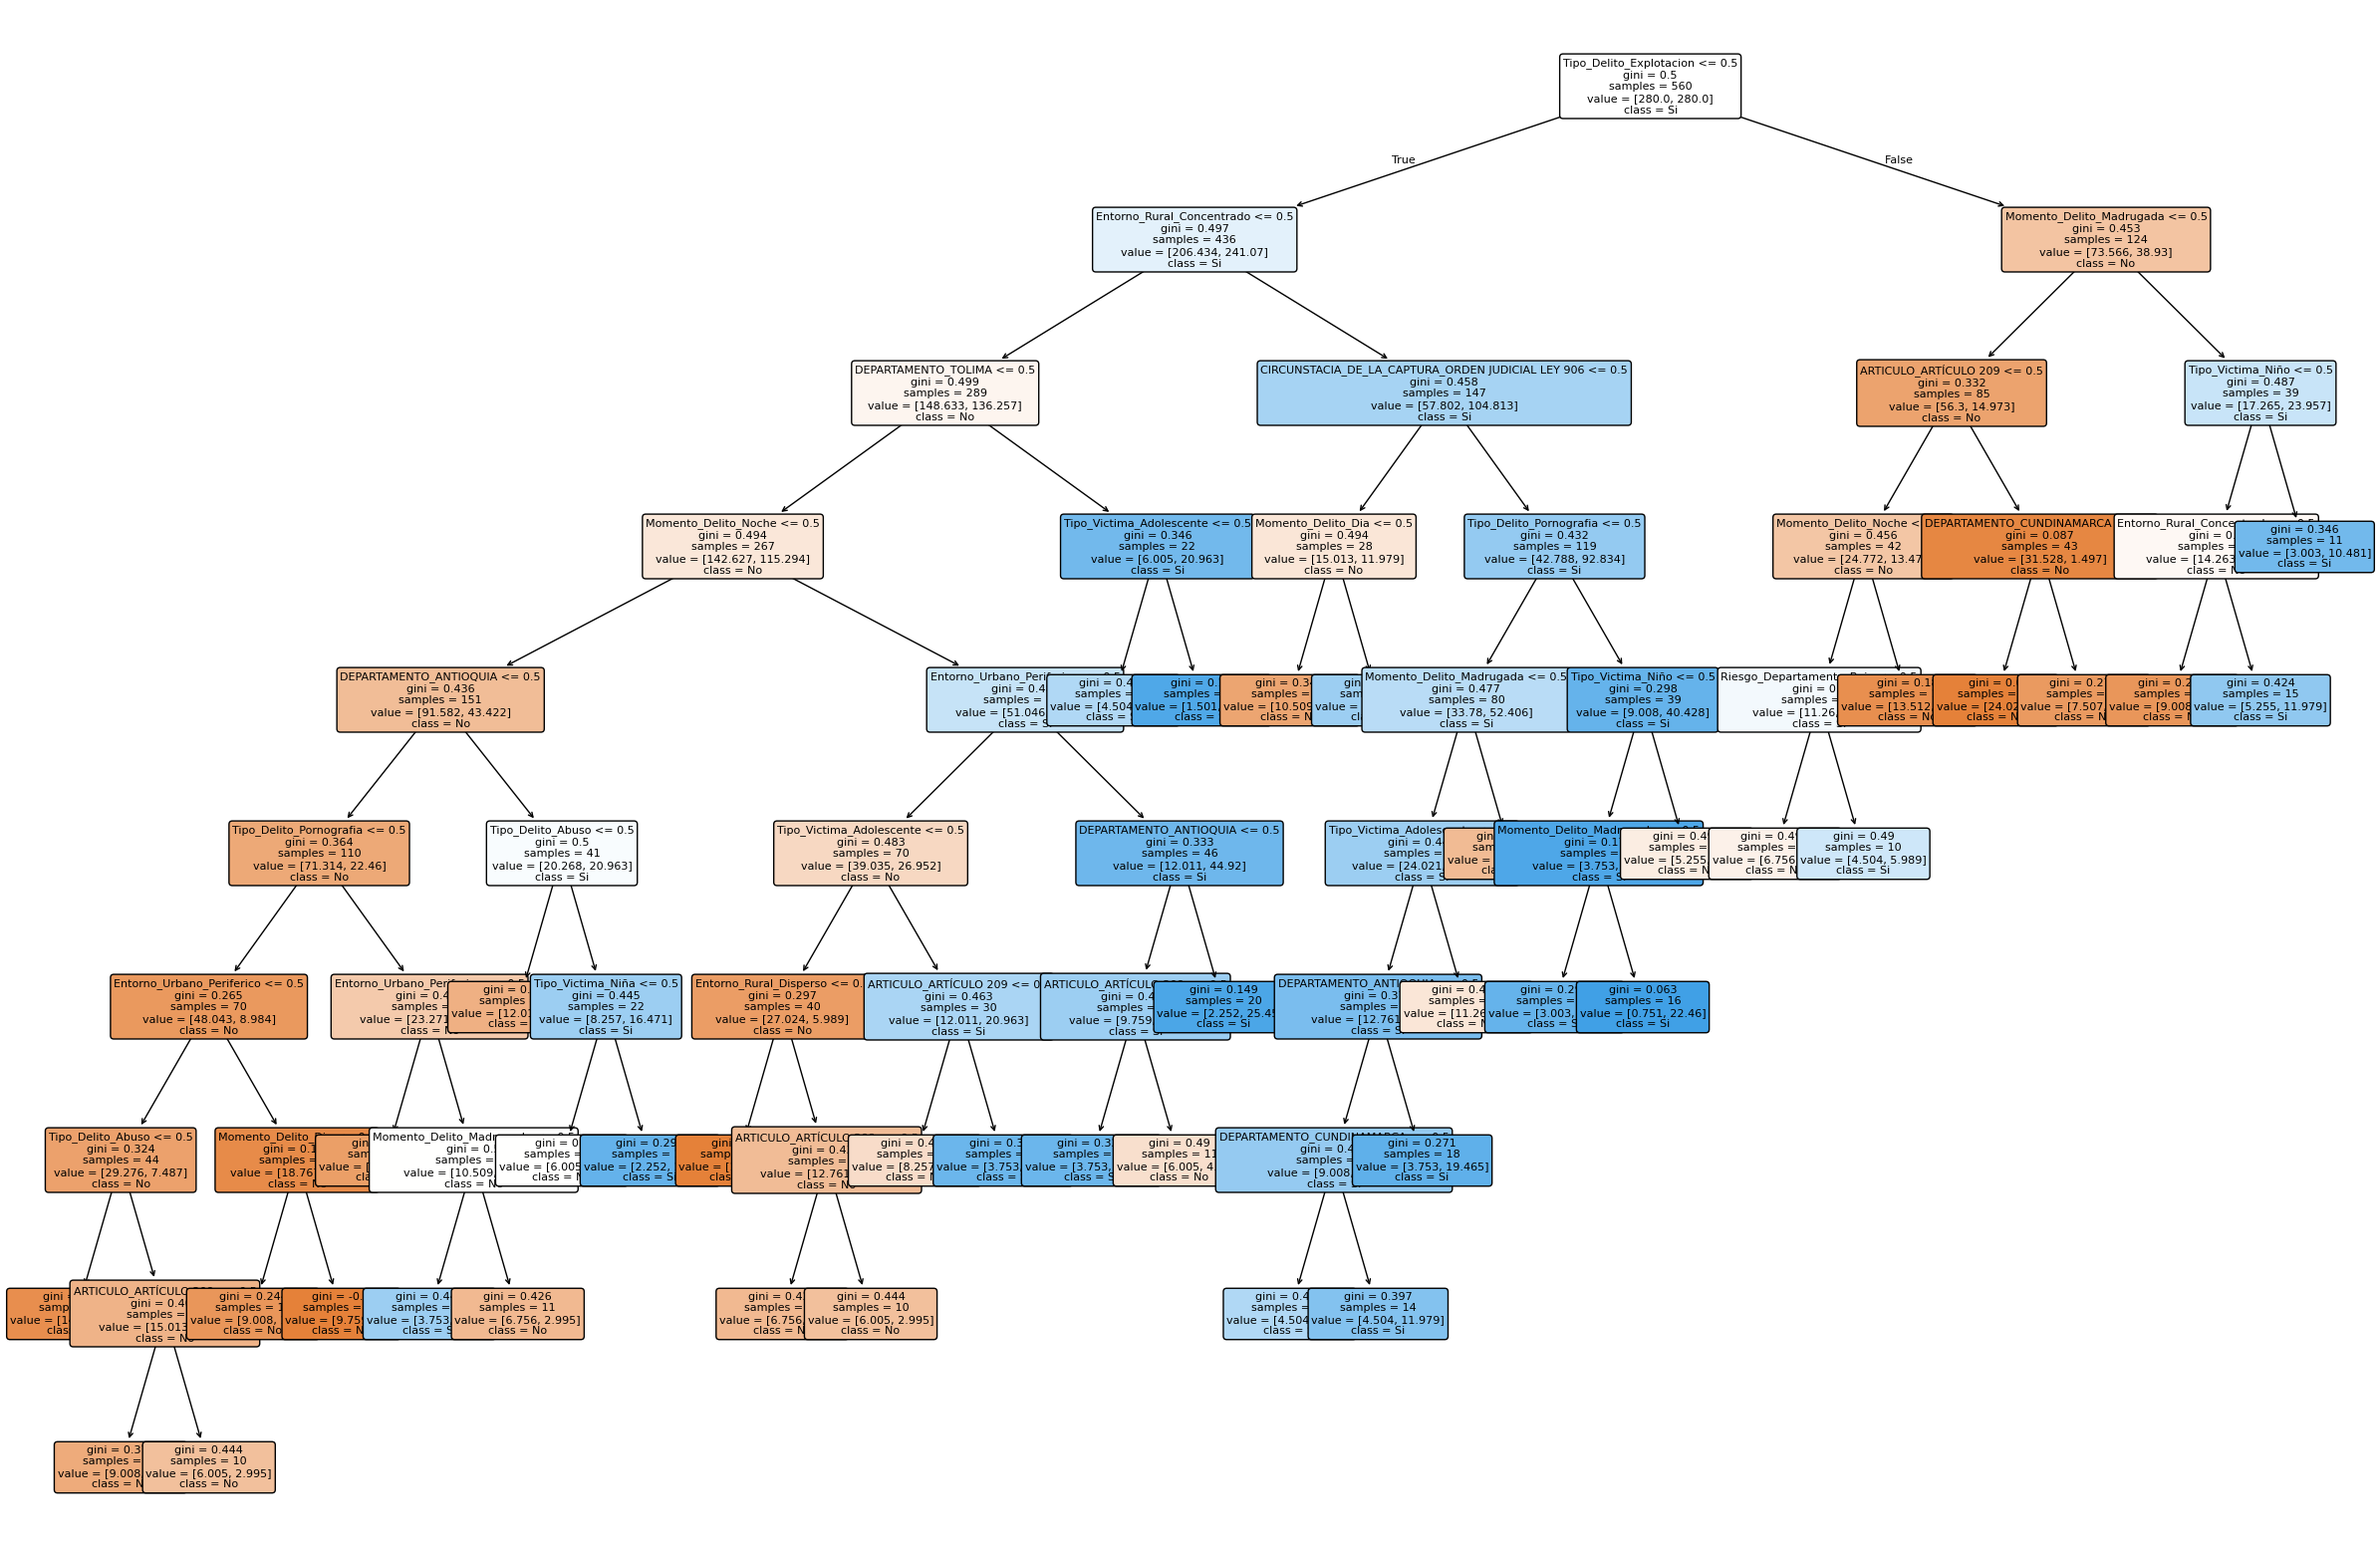

In [ ]:
from sklearn.tree import plot_tree
plt.figure(figsize=(30,20)) #Tamaño de la imagen
plot_tree(modelTree, feature_names=X_train.columns.values, class_names=labelencoder.classes_, rounded=True,  fontsize=8, filled=True)
plt.show()

In [ ]:
#Evaluación 30% (X_test)
from sklearn import metrics

Y_pred = modelTree.predict(X_test) #30% Test
print(Y_pred)

[0 0 1 0 0 0 0 0 0 0 1 0 1 1 0 1 1 1 0 1 0 1 0 0 1 1 1 0 1 0 0 1 0 0 1 0 0
 1 0 1 0 1 0 0 0 1 0 0 0 1 0 0 1 0 0 0 1 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1
 0 0 0 0 1 0 0 1 0 1 0 0 1 0 0 1 0 1 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1
 0 0 1 1 0 0 0 0 1 0 0 0 1 1 0 0 1 1 0 0 1 1 0 1 1 0 0 1 1 0 1 0 0 0 0 0 1
 1 1 1 0 1 0 0 1 1 0 0 1 0 1 0 1 0 0 0 0 0 0 0 1 0 1 0 0 1 1 0 0 1 1 0 1 0
 1 1 0 0 0 1 0 1 1 0 1 1 0 1 1 0 1 0 0 0 0 0 1 0 1 1 1 1 0 1 1 1 0 0 0 0 0
 0 1 0 0 1 1 1 0 1 1 0 1 1 1 0 0 1 0 0]


In [ ]:
exactitud=metrics.accuracy_score(y_true=Y_test, y_pred=Y_pred)
print(exactitud)

0.6929460580912863


In [ ]:
#Matriz de confusion
from sklearn import metrics

cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
cm

array([[116,  45],
       [ 29,  51]])

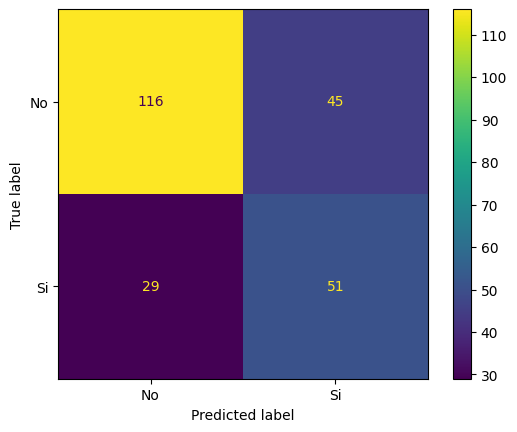

In [ ]:
#Plot de la matriz de confusion
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

In [ ]:
#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=labelencoder.classes_))

              precision    recall  f1-score   support

          No       0.80      0.72      0.76       161
          Si       0.53      0.64      0.58        80

    accuracy                           0.69       241
   macro avg       0.67      0.68      0.67       241
weighted avg       0.71      0.69      0.70       241



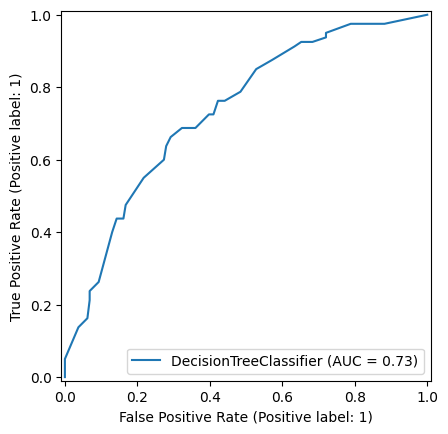

In [ ]:
metrics.RocCurveDisplay.from_estimator(modelTree,X_test, Y_test)

In [ ]:
from sklearn.metrics import roc_auc_score

# NO uses Y_pred (que son 0 y 1)
# USA las probabilidades de la clase positiva (clase 1)
Y_prob = modelTree.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(Y_test, Y_prob)
print(f"Nuevo AUC: {auc_score}")

Nuevo AUC: 0.7340062111801242


# **KNN**


In [ ]:
#Aprendizaje KNN con 70%
from sklearn.neighbors  import KNeighborsClassifier #KNeighborsRegressor

modelKnn = KNeighborsClassifier(n_neighbors=10, metric='minkowski')#euclidean, minkowski
modelKnn.fit(X_train, Y_train) #70%

KNeighborsClassifier(n_neighbors=10)

              precision    recall  f1-score   support

          No       0.74      0.86      0.80       161
          Si       0.59      0.40      0.48        80

    accuracy                           0.71       241
   macro avg       0.67      0.63      0.64       241
weighted avg       0.69      0.71      0.69       241



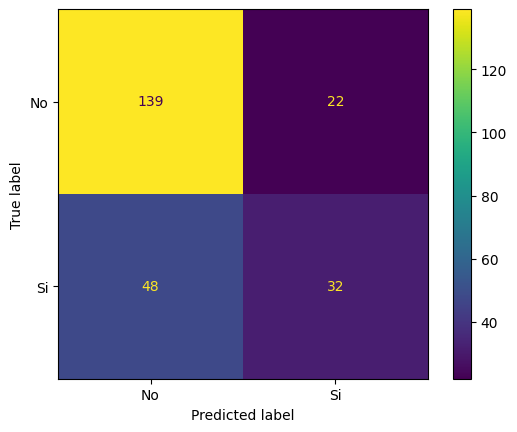

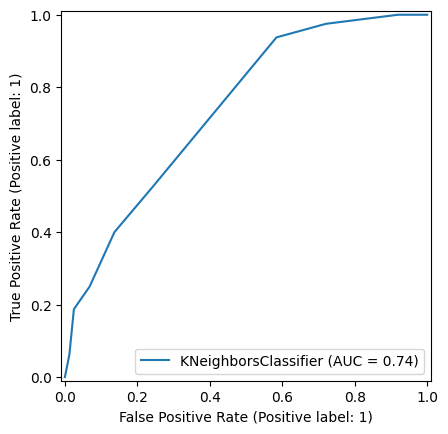

In [ ]:
#Evaluación de Knn con 30%
from sklearn import metrics

Y_pred = modelKnn.predict(X_test) #30%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=labelencoder.classes_))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(modelKnn,X_test, Y_test)

# **Red Neuronal**


In [ ]:
from sklearn.neural_network import MLPClassifier #MLPRegressor

#Solo se configura capas ocultas, no se configura capa de entrada y de salida
#activation -> función activación de la oculta: tanh, logistic, linear, relu
#hidden_layer_sizes=5,7 -> dos capas ocultas con 5 neuronas y 7 neuronas
#learning_rate-> tamaño del paso constante o decreciente (constant, adaptive)
#learning_rate_init-> valor tasa de aprendizaje
#momentum-> valor momentum
#max_iter-> iteaciones
#random_state-> semilla para generacion numeros seudoaletorios
modelNN = MLPClassifier(activation="relu",hidden_layer_sizes=(30), learning_rate='constant',
                     learning_rate_init=0.01, momentum= 0.03, max_iter=500, random_state=20)

modelNN.fit(X_train, Y_train) #70% normalizados

MLPClassifier(hidden_layer_sizes=30, learning_rate_init=0.01, max_iter=500,
              momentum=0.03, random_state=20)

              precision    recall  f1-score   support

          No       0.92      0.94      0.93       161
          Si       0.88      0.84      0.86        80

    accuracy                           0.91       241
   macro avg       0.90      0.89      0.90       241
weighted avg       0.91      0.91      0.91       241



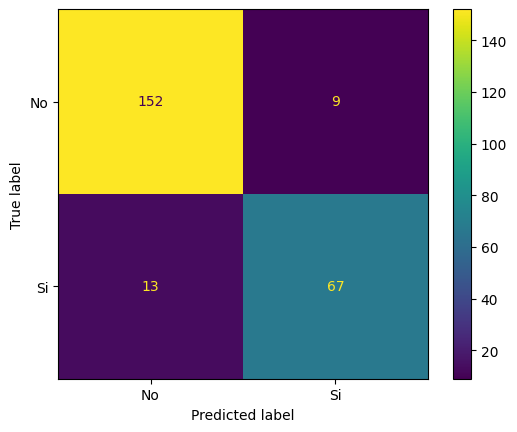

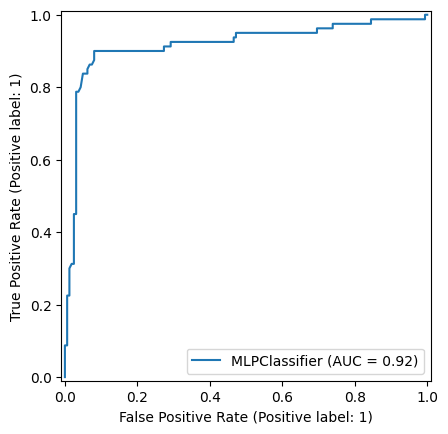

In [ ]:
#Evaluación de Red Neuronal
from sklearn import metrics

Y_pred = modelNN.predict(X_test) #30%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=labelencoder.classes_))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(modelNN,X_test, Y_test)

# **SVM**


In [ ]:
#SVM
from sklearn.svm import SVC # SVR

modelSVM = SVC(kernel='poly') #'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'
modelSVM.fit(X_train, Y_train) #70%

SVC(kernel='poly')

              precision    recall  f1-score   support

          No       0.80      0.88      0.84       161
          Si       0.69      0.56      0.62        80

    accuracy                           0.77       241
   macro avg       0.75      0.72      0.73       241
weighted avg       0.77      0.77      0.77       241



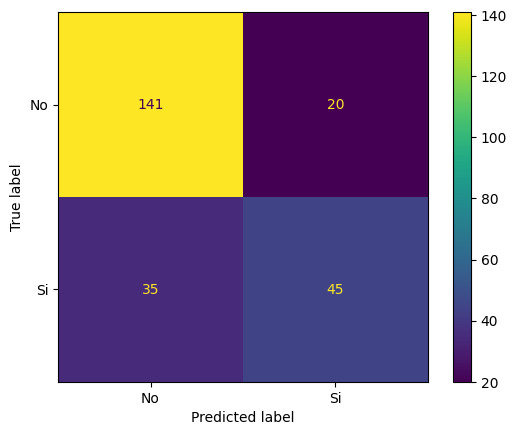

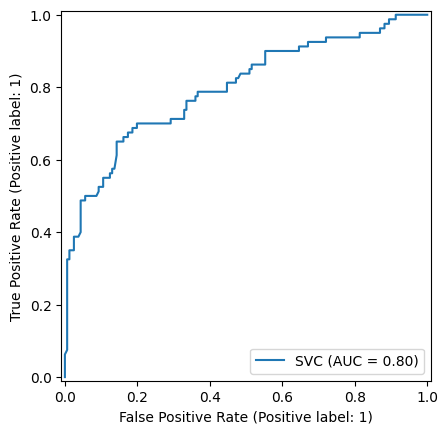

In [ ]:
#Evaluación de SVM
from sklearn import metrics

Y_pred = modelSVM.predict(X_test) #20%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=labelencoder.classes_))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(modelSVM,X_test, Y_test)

# **Regresión Logística**

In [ ]:
from sklearn.linear_model import LogisticRegression

# Creación del modelo de Regresión Logística
modelLR = LogisticRegression(max_iter=100, random_state=2)
modelLR.fit(X_train, Y_train) # 70% normalizados

LogisticRegression(random_state=2)

              precision    recall  f1-score   support

          No       0.72      0.86      0.79       161
          Si       0.55      0.34      0.42        80

    accuracy                           0.69       241
   macro avg       0.64      0.60      0.60       241
weighted avg       0.67      0.69      0.67       241



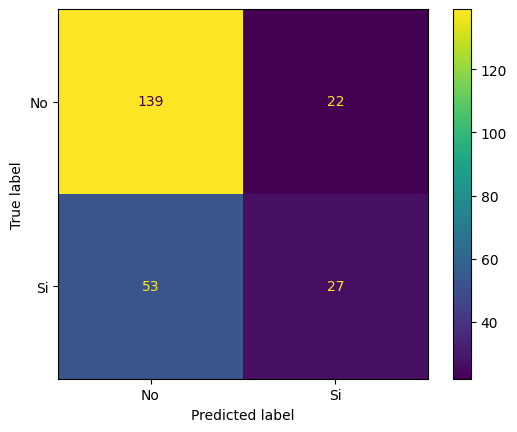

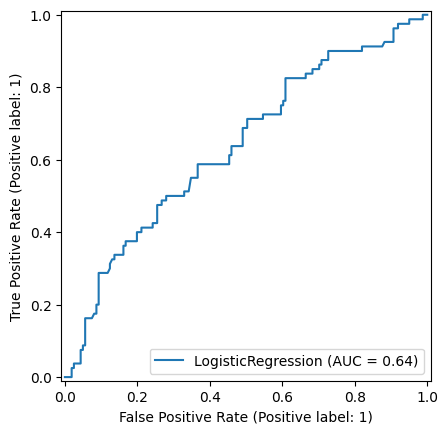

In [ ]:
#Evaluación de Reg logística
from sklearn import metrics

Y_pred = modelLR.predict(X_test) #20%

#Matriz de confusion
cm=metrics.confusion_matrix(y_true=Y_test, y_pred=Y_pred)
disp=metrics.ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=labelencoder.classes_)
disp.plot()

#Precision, Recall, f1, exactitud
print(metrics.classification_report( y_true=Y_test, y_pred=Y_pred, target_names=labelencoder.classes_))

# Curva ROC
metrics.RocCurveDisplay.from_estimator(modelLR,X_test, Y_test)

# **5.Guardamos el modelo**
-Se entrena  modelo final con 100% de los datos(X,Y)

In [ ]:
#Entrenamos modelo final
modelNN.fit(X,Y) #100%


MLPClassifier(hidden_layer_sizes=30, learning_rate_init=0.01, max_iter=500,
              momentum=0.03, random_state=20)

In [ ]:
import pickle
filename='modelo-class.pkl'
variables=X.columns.values
pickle.dump([modelNN, labelencoder, variables], open(filename, 'wb'))